# Supervised Machine Learning on Structural Brain Features

> This notebook evaluates the predictive signal in FreeSurfer ROI features using traditional ML models. The goals are to (1) confirm that HYDRA subtypes are separable in feature space, and (2) benchmark brain morphometry's predictive value for clinical/demographic outcomes.

**Models:** HistGradientBoosting (tuned), Logistic Regression (tuned), DummyClassifier/Regressor (baselines). All evaluated with subject-level train/test splits to prevent data leakage.

**Data:** Real ABCD analyses used N=2,387 participants with ComBat-harmonized features across 22 sites. Some demoed features use synthetic ROI features generated by `brainrisk.data.synthetic` (N=200, 400 features, 3 sites).

**Note:** The visualizations use aggregate, group-level summaries from ABCD data. All summaries have been previously disseminated in the author’s MSc thesis and do not permit identification of individual participants. This repository does not contain any ABCD Study data, subject-level results, or identifiable participant information. Some visualizations use synthetic data for reproducibility. Patterns in real data are discussed in inline annotations where they differ.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib_inline.backend_inline import set_matplotlib_formats

from brainrisk.baselines.classifiers import run_classification_suite
from brainrisk.baselines.interpretation import extract_feature_importance, map_to_atlas
from brainrisk.baselines.regressors import run_regression_suite
from brainrisk.data.clinical import load_and_merge, get_feature_columns, prepare_task
from brainrisk.data.splits import subject_split
from brainrisk.data.synthetic import generate_roi_features, generate_labels, generate_clinical_data
from brainrisk.utils.visualization import plot_baseline_comparison

# Figure resolution: adjust the DPI below to increase or decrease image quality.
# Currently set to 60 to keep the repository lightweight and fast to load.
set_matplotlib_formats('png')
mpl.rcParams["figure.dpi"] = 60
mpl.rcParams["savefig.dpi"] = 60

sns.set_theme(style="whitegrid", font_scale=1.05)

### 1. Run Baseline Suite and Show Performance (ABCD results)

The table shows tuned model performance vs. dummy baselines (ABCD results). The HYDRA subtype classification result (F1-macro = 0.80) is the strongest, confirming that subtypes represent genuinely separable neurobiological patterns in feature space.

In [2]:
OUT = Path("../artifacts/notebook_scratch")
N, SEED = 200, 42

labels_df = generate_labels(n_subjects=N, seed=SEED, output_dir=OUT)
generate_roi_features(n_subjects=N, n_features=400, n_sites=3, seed=SEED, output_dir=OUT)
generate_clinical_data(n_subjects=N, n_sites=3, seed=SEED, output_dir=OUT, labels=labels_df)

merged = load_and_merge(OUT / "roi" / "features.csv", OUT / "labels" / "clinical.csv")
feature_cols = get_feature_columns(merged)
train_df, test_df = subject_split(merged, test_size=0.2, stratify_col="hydra_subtype", seed=SEED)

# Classification: HYDRA subtype + Sex
all_clf = []
for task_name, target in [("HYDRA Subtype (3-class)", "hydra_subtype"), ("Sex (binary)", "sex")]:
    X_tr, y_tr, _ = prepare_task(train_df, target, feature_cols)
    X_te, y_te, _ = prepare_task(test_df, target, feature_cols)
    results = run_classification_suite(X_tr, X_te, y_tr, y_te, task_name=task_name, n_iter=10, cv=2, seed=SEED)
    all_clf.extend(results)

# Regression: Family income
X_tr, y_tr, _ = prepare_task(train_df, "family_income_k", feature_cols)
X_te, y_te, _ = prepare_task(test_df, "family_income_k", feature_cols)
all_reg = run_regression_suite(X_tr, X_te, y_tr, y_te, task_name="Family Income", n_iter=10, cv=2, seed=SEED)


Real-Data Baseline Model Performance (ABCD Study)


Task,Metric,Tuned,Dummy,Δ
HYDRA subtype (3-class),F1 Macro,0.795,0.355,+0.440
Maternal substance use (binary),F1 Macro,0.541,0.522,+0.019
Experienced bullying (binary),Recall Macro,0.532,0.498,+0.034
Having a regular group of friends,F1 Macro,0.376,0.323,+0.053
Parent psychopathology (binary),Precision Macro,0.357,0.333,+0.024
DSM-5 oppositional disorder,F1 Macro,0.405,0.33,+0.075
Family income,R²,0.121,≈ 0.000,+0.121
Parent education,R²,0.048,≈ 0.000,+0.048
Area deprivation index,R²,0.079,≈ 0.000,+0.079


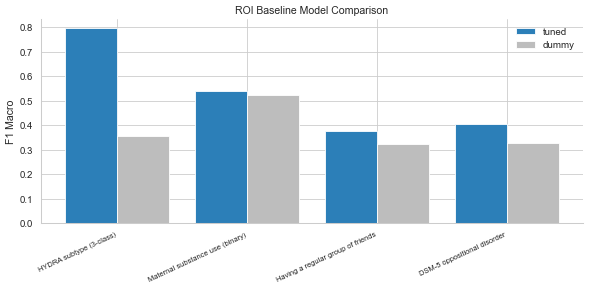

In [3]:
# Display results
clf_rows = [{"Task": r["task"], "Model": r["model_type"],
             "F1-macro": f"{r['metrics']['f1_macro']:.3f}",
             "Accuracy": f"{r['metrics']['accuracy']:.3f}"} for r in all_clf]
reg_rows = [{"Task": r["task"], "Model": r["model_type"],
             "R²": f"{r['metrics']['r2']:.3f}",
             "MAE": f"{r['metrics']['mae']:.1f}"} for r in all_reg]

show_real_abcd: bool = True
metrics_path = Path("../assets/data/baseline_metrics.json")

if not show_real_abcd:
    print(f"Train: {len(train_df)} | Test: {len(test_df)} | Features: {len(feature_cols)}")
    print("\n━━━ Classification Results (Synthetic Data) ━━━")
    display(pd.DataFrame(clf_rows))
    print("\n━━━ Regression Results (Synthetic Data) ━━━")
    display(pd.DataFrame(reg_rows))

elif show_real_abcd and metrics_path.exists():
    metrics = json.loads(metrics_path.read_text())

    # Build comparison table
    rows = []
    for key, info in metrics["classification"].items():
        best_key = [k for k in info if k.startswith("best_")][0] if any(k.startswith("best_") for k in info) else None
        dummy_key = [k for k in info if k.startswith("dummy_")][0] if any(k.startswith("dummy_") for k in info) else None
        metric_name = best_key.replace("best_", "") if best_key else "?"
        rows.append({
            "Task": info["task"],
            "Metric": metric_name.replace("_", " ").title(),
            "Tuned": f"{info.get(best_key, 'N/A')}" if best_key else "N/A",
            "Dummy": f"{info.get(dummy_key, 'N/A')}" if dummy_key else "N/A",
            "Δ": f"+{info[best_key] - info[dummy_key]:.3f}" if best_key and dummy_key else "",
        })
    for key, info in metrics["regression"].items():
        rows.append({
            "Task": info["task"],
            "Metric": "R²",
            "Tuned": f"{info['best_r2']:.3f}",
            "Dummy": "≈ 0.000",
            "Δ": f"+{info['best_r2']:.3f}",
        })

    print("Real-Data Baseline Model Performance (ABCD Study)")
    print("=" * 70)
    display(pd.DataFrame(rows).style.hide(axis="index"))

    # Visual comparison
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_baseline_comparison(json_path=metrics_path, ax=ax)
    plt.tight_layout()
    plt.show()

else:
    print("⚠ Baseline metrics data not found.")


### 2. Feature Importance: What Drives Subtype Classification?

Examining which brain regions the models rely on for subtype classification provides a complementary perspective to the ANCOVA-based effect sizes in Notebook 03.

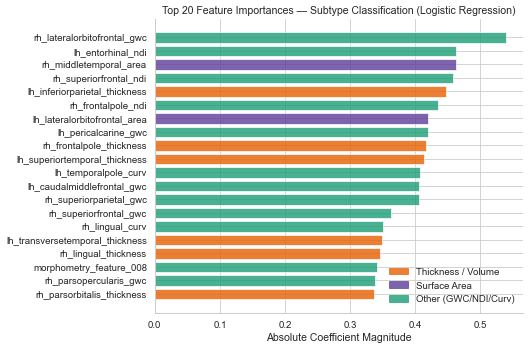

In [4]:
# Get the best classifier from the synthetic run
best_clf = next(r for r in all_clf if r["task"] == "HYDRA Subtype (3-class)" and r["model_type"] == "logistic")
pipe = best_clf["fitted_pipeline"]

imp_df = extract_feature_importance(pipe, feature_cols, method="model")
atlas_df = map_to_atlas(imp_df, top_n=20)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(9, 6))
top20 = imp_df.head(20).iloc[::-1]
colors = ["#e66101" if "thickness" in f or "volume" in f.lower()
          else "#5e3c99" if "area" in f
          else "#1b9e77" for f in top20["feature"]]
ax.barh(top20["feature"], top20["abs_importance"], color=colors, alpha=0.8)
ax.set_xlabel("Absolute Coefficient Magnitude")
ax.set_title("Top 20 Feature Importances — Subtype Classification (Logistic Regression)")
ax.spines[["top", "right"]].set_visible(False)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#e66101", alpha=0.8, label="Thickness / Volume"),
    Patch(color="#5e3c99", alpha=0.8, label="Surface Area"),
    Patch(color="#1b9e77", alpha=0.8, label="Other (GWC/NDI/Curv)"),
], frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

In [5]:
# Show atlas annotations for top features
print("\nTop 10 Features with Atlas Mapping:\n")
display(atlas_df[["feature", "hemisphere", "region", "measure", "abs_importance"]].head(10)
        .style.hide(axis="index").format({"abs_importance": "{:.4f}"}))


Top 10 Features with Atlas Mapping:



feature,hemisphere,region,measure,abs_importance
rh_lateralorbitofrontal_gwc,rh,lateralorbitofrontal,gwc,0.5392
lh_entorhinal_ndi,lh,entorhinal,ndi,0.4627
rh_middletemporal_area,rh,middletemporal,area,0.4622
rh_superiorfrontal_ndi,rh,superiorfrontal,ndi,0.4586
lh_inferiorparietal_thickness,lh,inferiorparietal,thickness,0.4469
rh_frontalpole_ndi,rh,frontalpole,ndi,0.4353
lh_lateralorbitofrontal_area,lh,lateralorbitofrontal,area,0.4205
lh_pericalcarine_gwc,lh,pericalcarine,gwc,0.4200
rh_frontalpole_thickness,rh,frontalpole,thickness,0.4160
lh_superiortemporal_thickness,lh,superiortemporal,thickness,0.4143


---
**Summary:**
- **HYDRA subtype classification** is the strongest result (F1-macro = 0.80 on real data), confirming genuine subtype separability in brain morphometry.
- **Sociodemographic prediction** from ROI features is modest but above chance: brain structure carries weak but real signal about environmental context (income R² = 0.12).